# Modelos VARMAX (Vector AutRegression Moving Avarage with Exogenous Variables)

Neste notebook, vamos estudar o modelo VARMAX, uma extensão do VAR que permite:

- Componentes de média móvel (MA)
- Variáveis exógenas (X)

## Onjetivos:
- Entender a estrutura do VARMAX
- Compreender representação em State-Space
- Trabalhar com variáveis exógenas
- Comparar o VAR vs VARMAX
- Aplicar em um exemplo prático

## Contexto:

VARMAX é amplamente usado em:

- economia
- Engenharia
- Sistemas dinâmicos
- Séries temporais multivaridas com influência externa

In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.api import VAR
from statsmodels.tsa.statespace.varmax import VARMAX

plt.style.use('dark_background')
np.random.seed(42)

## Intuição do VARMAX

O modelo VARMAX(p, q) com variáveis exógenas é dado por:

$Y_t = \sum_{i=1}^{p} A_i Y_{t-i} + \sum_{j=1}^{q} B_j \varepsilon_{t-j} + C X_t + \varepsilon_t$

Onde:
- Y_t → vetor de variáveis endógenas
- X_t → variáveis exógenas
- ε_t → ruído branco

Diferença chave:
- VAR: só usa Y
- VARMAX: usa Y + erros passados + variáveis externas


## Representação em State-Space

O VARMAX pode ser representado como um modelo de espaço de estados:

### Equação de estado:
$\alpha_t = T \alpha_{t-1} + R \epsilon_t$

### Equação de observação:
$Y_t = Z \alpha_t + D X_t + \epsilon_t$

Onde:
- $\alpha_t \rightarrow$ estado oculto
- $Y_t \rightarrow$ observação
- $X_t\rightarrow$ variável exógena


Essa repsetnação permite:
- Filtro de Kalman
- Estimação eficiente
- Previsões robustas

*É assim que a biblioteca statsmodels implementa o VARMAX*


In [3]:
# Simulando Dados
n = 200

# Variável exógena (ex: temperatura, preço externo, etc)
exog = np.random.normal(0, 1, n)

# Ruído
e1 = np.random.normal(0, 1, n)
e2 = np.random.normal(0, 1, n)

x = np.zeros(n)
y = np.zeros(n)

for t in range(1, n):
    x[t] = 0.6 * x[t-1] + 0.3 * exog[t] + e1[t]
    y[t] = 0.4 * y[t-1] + 0.2 * x[t-1] + 0.5 * exog[t] + e2[t]

df = pd.DataFrame({
    "X": x,
    "Y": y
})

df_exog = pd.DataFrame({
    "Exog": exog
})

df.head()

,X,Y
0,0.000000,0.000000
1,0.519305,-0.668507
2,1.588941,0.165546
3,2.464076,1.192502
4,0.030530,0.402674


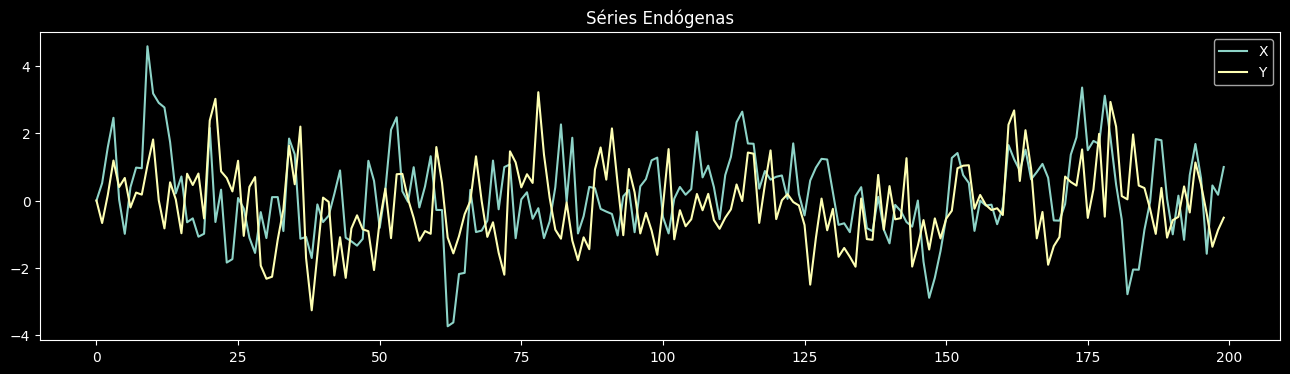

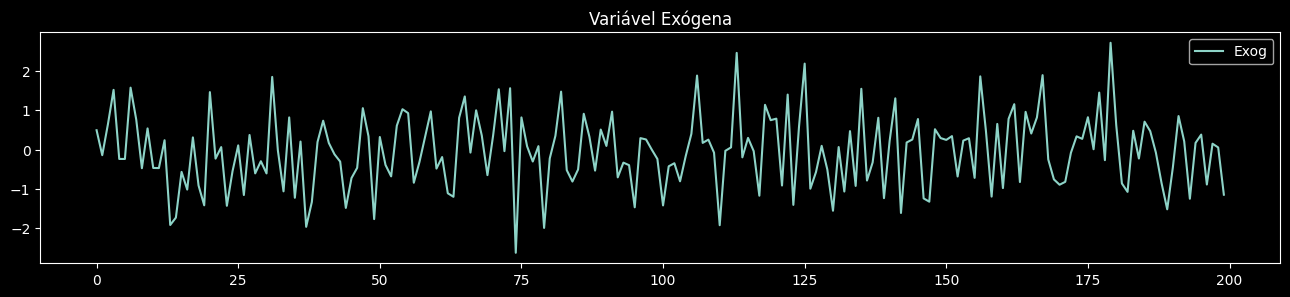

In [5]:
# Visualização

df.plot(figsize=(16, 4), title="Séries Endógenas")
plt.show()

df_exog.plot(figsize=(16, 3), title="Variável Exógena")
plt.show()

In [6]:
# Ajustando VAR (baseline)
modelo_var = VAR(df)
resultado_var = modelo_var.fit(maxlags=1)

print(resultado_var.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Thu, 26, Mar, 2026
Time:                     03:20:12
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                   0.309823
Nobs:                     199.000    HQIC:                  0.250715
Log likelihood:          -579.685    FPE:                    1.23434
AIC:                     0.210528    Det(Omega_mle):         1.19794
--------------------------------------------------------------------
Results for equation X
           coefficient       std. error           t-stat            prob
------------------------------------------------------------------------
const         0.066227         0.075993            0.871           0.383
L1.X          0.587942         0.059792            9.833           0.000
L1.Y         -0.067808         0.066318           -1.022           0.307

Results for equation Y

In [7]:
#Ajustando VARMAX
modelo_varmax = VARMAX(df, exog=df_exog, order=(1, 1))
resultado_varmax = modelo_varmax.fit(disp=False)

print(resultado_varmax.summary())

/home/isaac-kosloski/anaconda3/envs/varmax/lib/python3.11/site-packages/statsmodels/tsa/statespace/varmax.py:160: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'


                           Statespace Model Results                           
Dep. Variable:             ['X', 'Y']   No. Observations:                  200
Model:                    VARMAX(1,1)   Log Likelihood                -555.850
                          + intercept   AIC                           1141.700
Date:                Thu, 26 Mar 2026   BIC                           1191.174
Time:                        03:25:13   HQIC                          1161.721
Sample:                             0                                         
                                - 200                                         
Covariance Type:                  opg                                         
Ljung-Box (L1) (Q):             0.03, 0.00   Jarque-Bera (JB):           6.25, 0.99
Prob(Q):                        0.86, 0.98   Prob(JB):                   0.04, 0.61
Heteroskedasticity (H):         0.68, 0.86   Skew:                       0.22, 0.17
Prob(H) (two-sided):            0.11,

## Comparação VAR vs VARMAX

| Modelo | Usa exógenas | Usa MA | Complexidade |
|--------|-------------|--------|-------------|
| VAR    | ❌           | ❌      | Baixa       |
| VARMAX | ✅           | ✅      | Alta        |

Esperado:
- VARMAX deve capturar melhor dinâmica se X_t for relevante

In [8]:
print("AIC VAR:", resultado_var.aic)
print("AIC VARMAX:", resultado_varmax.aic)

AIC VAR: 0.21052785597511636
AIC VARMAX: 1141.699719600209


In [9]:
# Criando exógena futura
exog_futuro = np.random.normal(0, 1, 10)
df_exog_futuro = pd.DataFrame({"Exog": exog_futuro})

previsao_varmax = resultado_varmax.forecast(steps=10, exog=df_exog_futuro)

previsao_varmax

/home/isaac-kosloski/anaconda3/envs/varmax/lib/python3.11/site-packages/statsmodels/tsa/statespace/varmax.py:160: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'
/home/isaac-kosloski/anaconda3/envs/varmax/lib/python3.11/site-packages/statsmodels/tsa/statespace/varmax.py:160: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'


,X,Y
200,0.861492,0.390465
201,0.245577,-0.201140
202,0.596326,0.196223
203,1.024430,0.528681
204,0.904584,0.335431
205,1.434159,0.786322
206,0.669598,0.028655
207,-0.016006,-0.450163
208,-0.671953,-0.854426
209,0.275698,0.131133


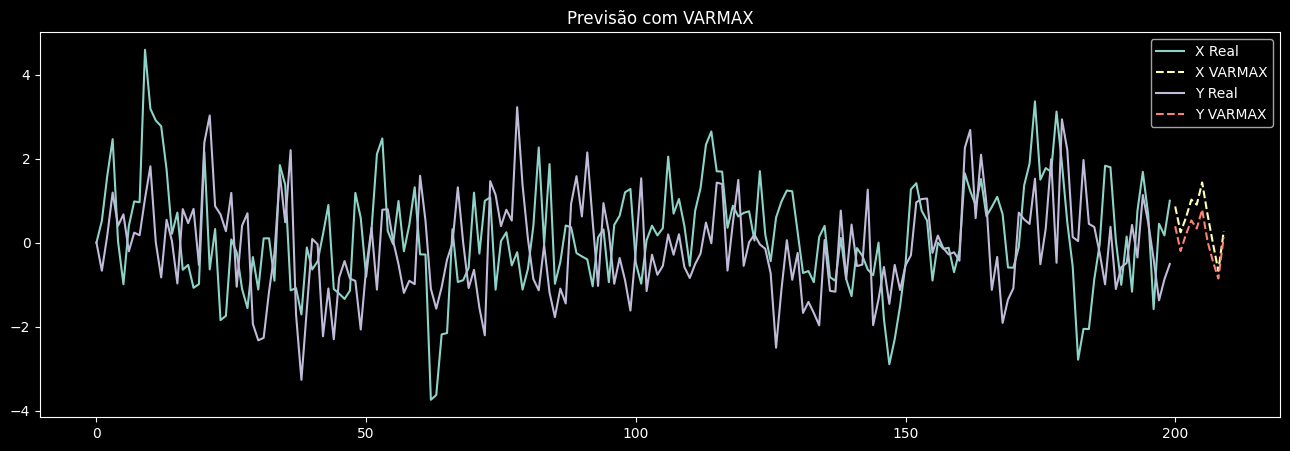

In [11]:
# Plot das Previsões
plt.figure(figsize=(16, 5))

for coluna in df.columns:
    plt.plot(df[coluna], label=f"{coluna} Real")
    plt.plot(range(len(df), len(df)+10),
             previsao_varmax[coluna],
             '--',
             label=f"{coluna} VARMAX")

plt.legend()
plt.title("Previsão com VARMAX")
plt.show()

## Conclusão

Neste notebook, aprendemos:

- Estrutura do modelo VARMAX
- Representação em State-Space
- Uso de variáveis exógenas
- Diferença entre VAR e VARMAX
- Aplicação prática com simulação

## Próximos passos (nível avançado):

- Diagnóstico de resíduos
- Seleção de ordem automática
- Forecast multi-step robusto
- Integração com dashboard (Streamlit)

🚀 Agora você tem base completa para usar VARMAX no seu projeto